# Script to use the 1990-2023 climatological average start and end of summer for the NH and track how the gradient is changing over time on those days. This should provide additional evidence that, for a sinusoidal pattern to the T2m time series, as the curve moves upward from rising temps, the curve gets steeper as it passes through the 75th percentile temp threshold for the start/end of summer.

In [1]:
# includes
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

import scipy.stats as stats
from sklearn import linear_model
import statsmodels.api as sm
import seaborn as sns

# to get rid of runtime warnings when OLS fits hit a divide by zero - handled by setting R2 and p-vals appropriately
import warnings
warnings.filterwarnings('ignore')

# Lat limits
nh_min = 23.5
nh_max = 70

In [31]:
# function to calculate gradients on the start/end DOY from climatology
def GetGradAtClimStartEnd(temp_data, clim_start, clim_end, show_plot):
    ''' function uses the start and end days from DOY climatology data and calculates the gradients of the Fourier fit to the annual T2m time series on those days
    for a specific lat/lon location. Designed to be used in a loop over all lat/lon values over all years.

    These results can be analyzed for whether this gradient is changing over time and how it differs by location

    Args:
        temp_data: xarray of temperature data for a single grid cell for the year of interest
        clim_start: the DOY that the climatology data (here expecting 1990-2023) crosses the 75th percentile temp from baseline 1961-1990 from below to above
        clim_end: the DOY that the climatology data (here expecting 1990-2023) crosses the 75th percentile temp from baseline 1961-1990 from above to below
        show_plot: boolean as to whether we should print out the start and end gradients and show the plot of the gradient for every DOY

    Returns:
        
        grad_start: the gradient of the Fourier fit to the T2m data on the start DOY based on the rolling avg climatology
        grad_end: the gradient of the Fourier fit to the T2m data on the end DOY based on the rolling avg climatology
        

    Example: start_grad, end_grad = GetGradAtClimStartEnd(temp_data, 100, 200, True)

    '''

    # set defaults
    # gradients at the start and end of the summer from the fourier fit
    grad_start = 0
    grad_end = 0

    # determine x & y for fits
    x1 = temp_data.time.dt.dayofyear.values
    y1 = temp_data.values

    # create some x values for plotting fits
    x_values = np.linspace(min(x1), max(x1), 365)

    ### Fourier
    # Fourier fit, up to 4th harmonic (mean + 3 more) as in Weller et al 2020
    ymean = np.mean(y1)
    y_norm = y1 - ymean
    # perform DFT of temp data
    coef = fft(y_norm)
    # low-pass filter: retain only the mean and the first three harmonics, set all other frequencies to zero
    # help from https://kls2177.github.io/Climate-and-Geophysical-Data-Analysis/chapters/Week6/filtering_in_freq2.html
    Z_lp = np.copy(coef)
    Z_lp[4:-3:] = 0.0  # we have to set both the positive and negative frequencies to zero
    # apply inverse fourier transform to convert back to time domain (just want the real part)
    y_norm_lp = np.real(np.fft.ifft(Z_lp))
    
    # add back in the original mean temp
    y_lp = y_norm_lp + ymean
    
    # RMSE for Fourier fit to the roll avg climatology
    rmse_f = np.sqrt(np.sum((y1-y_lp)**2)/365.0)
    

    ####################
    # CALCULATE THE GRADIENTS
    ####################
    grad_fourier = np.gradient(y_lp)
    grad_start = grad_fourier[clim_start-1]
    grad_end = grad_fourier[clim_end-1]


    
    # make and save plot if desired
    ##
    ##
    if show_plot:
        # print summer stats from each
        print("Gradient of Fourier Fit at clim start: "+str(grad_start)+" and at clim end: "+str(grad_end))

        # get lat and lon for plot title
        cell_lat = temp_data.lat.values
        cell_lon = temp_data.lon.values
        
        plt.figure(figsize=(12,8))

        # temp time series plot with fit
        plt.subplot(211)
        yr = temp_data.time.dt.year.values[0]

        plt.plot(x1,y1, label='daily mean T2m')
        plt.plot(x_values, y_lp, label='Fourier fit 1-4th Harmonic', color='red')
        plt.axvline(clim_start, color="black", linewidth=0.8, linestyle="dashed")
        plt.axvline(clim_end, color="black", linewidth=0.8, linestyle="dashed")
        #plt.annotate('start', xy=(first_day-5,np.max(y_lp)+2), fontsize=12)
        #plt.annotate('end', xy=(last_day-5,np.max(y_lp)+2), fontsize=12)
        plt.xlabel('DOY (' + str(yr) + ')')
        plt.ylabel('Mean Daily Temp (K)')
        plt.title(str(yr) + " Summer for Lat,Lon = [" +str(cell_lat)+","+str(cell_lon)+ "] Baseline Years = (1961-1990)")
        plt.legend()
        
        # gradient of each vs doy plot
        plt.subplot(212)
        plt.plot(x_values, grad_fourier, label='Gradient of Fourier fit', color='red')
        plt.axhline(0.0, color="black", linewidth=0.8, linestyle="dashed")
        # start and end of climatological average summer
        plt.axvline(clim_start, color="black", linewidth=0.8, linestyle="dashed")
        plt.axvline(clim_end, color="black", linewidth=0.8, linestyle="dashed")  
        plt.legend()
        plt.xlabel('DOY')
        plt.ylabel('$\Delta$ Mean Daily Temp (K)')
        plt.title("Gradient "+str(yr)+" Summer for Lat,Lon = [" +str(cell_lat)+","+str(cell_lon)+ "] Baseline Years = (1961-1990)")
        

        
        #plt.savefig("fourierfit_stats_"+str(cell_lat)+"_"+str(cell_lon)+"_"+str(yr)+".png")
        
        
        plt.tight_layout()
        plt.show()
        

    # returns
    return float(grad_start), float(grad_end)

# a function that takes in a dataset of global t2m values and if it is a leap year averages
# the temps on Feb 28 & Feb 29, then drops Feb 29 to ensure the year has 365 days
def HandleLeapYears(input_ds):
    '''

    Function that takes the mean of Feb 28 & Feb 29 (if it exists) and returns an xarray Dataset that has 365 days
    where Feb 28 will now have a t2m value that is the mean of Feb 28 & Feb 29

    Args:
        input_ds: the data set containing a single year of data that may need adjusting for leap year
        
    Returns:
        output_ds
        
    Example:
        no_leap_ds = HandleLeapYears(input_ds)

    '''
    

    # check if a leap year
    if(input_ds.time.dt.is_leap_year[0].values):
        
        # make deep copy
        output_ds = input_ds.copy(deep=True)
        
        # get mean of Feb 28 (time index 58) & Feb 29 (time index 59) for each grid cell and overwrite Feb 28 with it
        mean_dat = output_ds.t2m[58:60].mean(dim='time', skipna=True, keep_attrs=True)
        output_ds.t2m[58] = mean_dat
        
        # drop Feb 29
        output_ds = output_ds.convert_calendar('noleap', use_cftime=None)

        # ensure time is datetime64
        output_ds["time"] = output_ds.time.dt.strftime('%Y-%m-%d')
        output_ds['time'] = pd.to_datetime(output_ds['time'])

        # return the new dataset 
        return output_ds
    else:
        return input_ds

## read in all the data from the analysis years and reduce to NH midlatitudes

### will merge in lsm and coastal flags from the clim data file

In [16]:
%%time

# test one year
input_year = 2023

# get this year and next year's daily mean t2m data
if input_year <= 1990:
    file_path = '../../../Data/ERA5-global/Baseline/' + str(input_year) + '/*.nc'
else:
    file_path = '../../../Data/ERA5-global/Analysis/' + str(input_year) + '/*.nc'
ds = xr.open_mfdataset(file_path)

# remove leap day by averaging Feb 28 & 29 together before dropping Feb 29
ds = HandleLeapYears(ds)

# load into memory to speed up the summer stats processing
ds.load()

# reduce to NH only
ds = ds.sel(lat=slice(nh_min, nh_max))
ds


CPU times: user 362 ms, sys: 1.75 s, total: 2.11 s
Wall time: 2.82 s


<xarray.Dataset> Size: 786MB
Dimensions:      (time: 365, lat: 187, lon: 1440)
Coordinates:
  * time         (time) datetime64[ns] 3kB 2023-01-01 2023-01-02 ... 2023-12-31
    realization  int64 8B 0
  * lat          (lat) float64 1kB 23.5 23.75 24.0 24.25 ... 69.5 69.75 70.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    sst          (time, lat, lon) float32 393MB 298.5 298.7 ... 271.5 271.5
    t2m          (time, lat, lon) float32 393MB 296.7 296.8 ... 249.6 249.8
Attributes:
    Conventions:  CF-1.7
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      2024-09-02T04:12 GRIB to CDM+CF via cfgrib-0.9.9.1/ecCodes-...
    source:       ECMWF

## read in the climatology data to get start/end days from climatology

In [3]:
input_path = '../../../Data/ERA5-global/Analysis/New-Fourier/1990-2023_NH_gradient_stats.nc'
ds_clim = xr.open_dataset(input_path)
ds_clim

<xarray.Dataset> Size: 28MB
Dimensions:                   (lat: 187, lon: 1440)
Coordinates:
  * lat                       (lat) float64 1kB 23.5 23.75 24.0 ... 69.75 70.0
  * lon                       (lon) float64 12kB -180.0 -179.8 ... 179.5 179.8
Data variables: (12/14)
    RMSEFourier               (lat, lon) float64 2MB ...
    RMSEPoly                  (lat, lon) float64 2MB ...
    RMSEGradFourier           (lat, lon) float64 2MB ...
    RMSEGradPoly              (lat, lon) float64 2MB ...
    ClimAvgStartDOY           (lat, lon) float64 2MB ...
    ClimAvgEndDOY             (lat, lon) float64 2MB ...
    ...                        ...
    StartDeviationPoly        (lat, lon) float64 2MB ...
    EndDeviationPoly          (lat, lon) float64 2MB ...
    GradientSummStartFourier  (lat, lon) float64 2MB ...
    GradientSummEndFourier    (lat, lon) float64 2MB ...
    lsm                       (lat, lon) float64 2MB ...
    Coastal                   (lat, lon) bool 269kB ...

### Test for Vancouver

In [17]:
# test it for Vancouver of course
input_lat = 49.246
input_lon = -123.116

temp_data = ds.t2m.sel(lat=input_lat,lon=input_lon, method='nearest')
clim_data = ds_clim.sel(lat=input_lat, lon=input_lon, method='nearest')


In [24]:
#temp_data.values

158 265
Gradient of Fourier Fit at clim start: 0.07040405 and at clim end: -0.17913818


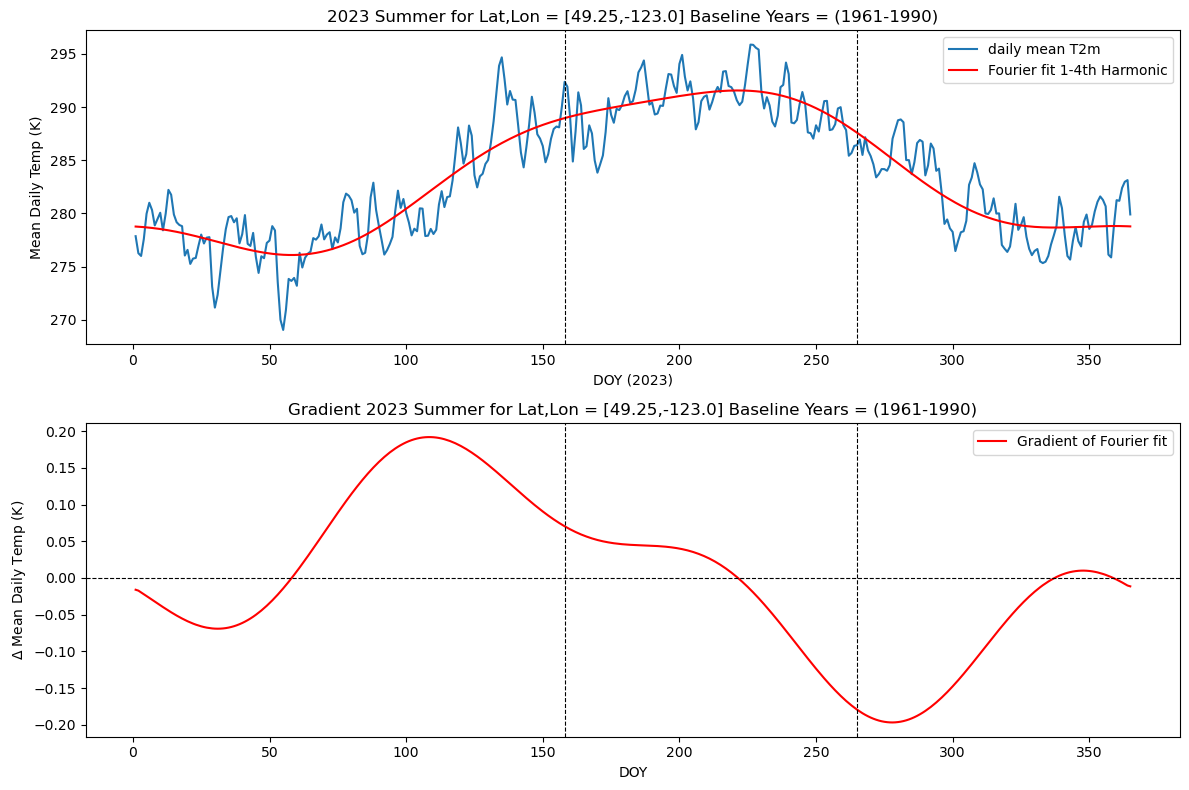

In [32]:
clim_start = int(clim_data.ClimAvgStartDOY.values.squeeze())
clim_end = int(clim_data.ClimAvgEndDOY.values.squeeze())
print(clim_start, clim_end)
start_grad, end_grad = GetGradAtClimStartEnd(temp_data, clim_start, clim_end, True)

## Process all years and locations - Fourier fit to smooth, calc gradient on the clim start/end days for each year and location

In [33]:
# get size of data for building data set and also loop parameters
loop_lats = ds.lat.values
loop_lons = ds.lon.values
num_lat = loop_lats.size
num_lon = loop_lons.size
loop_lats, loop_lons, num_lat, num_lon

(array([23.5 , 23.75, 24.  , 24.25, 24.5 , 24.75, 25.  , 25.25, 25.5 ,
        25.75, 26.  , 26.25, 26.5 , 26.75, 27.  , 27.25, 27.5 , 27.75,
        28.  , 28.25, 28.5 , 28.75, 29.  , 29.25, 29.5 , 29.75, 30.  ,
        30.25, 30.5 , 30.75, 31.  , 31.25, 31.5 , 31.75, 32.  , 32.25,
        32.5 , 32.75, 33.  , 33.25, 33.5 , 33.75, 34.  , 34.25, 34.5 ,
        34.75, 35.  , 35.25, 35.5 , 35.75, 36.  , 36.25, 36.5 , 36.75,
        37.  , 37.25, 37.5 , 37.75, 38.  , 38.25, 38.5 , 38.75, 39.  ,
        39.25, 39.5 , 39.75, 40.  , 40.25, 40.5 , 40.75, 41.  , 41.25,
        41.5 , 41.75, 42.  , 42.25, 42.5 , 42.75, 43.  , 43.25, 43.5 ,
        43.75, 44.  , 44.25, 44.5 , 44.75, 45.  , 45.25, 45.5 , 45.75,
        46.  , 46.25, 46.5 , 46.75, 47.  , 47.25, 47.5 , 47.75, 48.  ,
        48.25, 48.5 , 48.75, 49.  , 49.25, 49.5 , 49.75, 50.  , 50.25,
        50.5 , 50.75, 51.  , 51.25, 51.5 , 51.75, 52.  , 52.25, 52.5 ,
        52.75, 53.  , 53.25, 53.5 , 53.75, 54.  , 54.25, 54.5 , 54.75,
      

### Main Loop: loop through multiple years to generate summer stats

In [35]:
# process_yrs = [1990,1991,1992,1993, 1994, 1995, 1996, 1997, 1998, 1999, 2002, 2004, 2005, 2006, 2007, 2008,
#               2009, 2010, 2011, 2012, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
process_yrs = np.arange(1990, 1991,1)

process_yrs

array([1990])

In [ ]:
%%time

# Runtime: XX min for 1 year
# XX for 34 years

# loop thru the years in the defined array above
for input_year in process_yrs:

    # get this year and next year's daily mean t2m data
    if input_year <= 1990:
        file_path = '../../../Data/ERA5-global/Baseline/' + str(input_year) + '/*.nc'
    else:
        file_path = '../../../Data/ERA5-global/Analysis/' + str(input_year) + '/*.nc'
    ds = xr.open_mfdataset(file_path)

    # remove leap day by averaging Feb 28 & 29 together before dropping Feb 29
    ds = HandleLeapYears(ds)

    # load into memory to speed up the summer stats processing
    ds.load()

    # reduce to NH only
    ds = ds.sel(lat=slice(nh_min, nh_max))

    # empty data arrays for stats
    start_grad = xr.DataArray(np.zeros((num_lat,num_lon)), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])

    end_grad = xr.DataArray(np.zeros((num_lat,num_lon)), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])
    
    # add attributes
    start_grad.attrs["long_name"] = "Gradient of Fourier Fit at Summer Start according to Climatology"
    start_grad.attrs["units"] = "Deg/Day"
    end_grad.attrs["long_name"] = "Gradient of Fourier Fit at Summer End according to Climatology"
    end_grad.attrs["units"] = "Deg/Day"

    # loop through all of the lat,lon of interest
    for input_lat in loop_lats:
        for input_lon in loop_lons:
        
            # get data for this location
            temp_data = ds.t2m.sel(lat=input_lat,lon=input_lon, method='nearest')
            clim_data = ds_clim.sel(lat=input_lat, lon=input_lon, method='nearest')

            # get start and end from the climatology start/enddays
            clim_start = int(clim_data.ClimAvgStartDOY.values.squeeze())
            clim_end = int(clim_data.ClimAvgEndDOY.values.squeeze())

            # get gradient results
            start_gr, end_gr = GetGradAtClimStartEnd(temp_data, clim_start, clim_end, False)
    
            
            # xarray requires strange indexing in order to replace values by coordinate
            start_grad.loc[input_lat, input_lon] = start_gr
            end_grad.loc[input_lat, input_lon] = end_gr
            

    # save it out
    grad_ds = xr.Dataset(data_vars={'GradientAtClimSummStart':start_grad,
                                   'GradientAtClimSummEnd':end_grad})
    
    output_path = '../../../Data/ERA5-global/Analysis/New-Fourier/Gradients/ClimStartEnd/'+str(input_year)+'_gradients.nc'
    grad_ds.to_netcdf(output_path)

    # plots for the year
    ##############
    # Global summer mean temp for the year
    fig = plt.figure(figsize=(12,6))
    
    # assign axis and def projection to use
    ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))
    
    # add coastlines and grid
    ax.coastlines()
    ax.gridlines()
    
    grad_ds.GradientAtClimSummStart.plot(
        ax=ax,
        transform=ccrs.PlateCarree(), # assign map projection
        #vmin=250,
        #vmax=320, # define range to include an entire year
        cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
    )
    
    plt.title("Gradient on the Clim Summer Start for "+str(input_year))#+" using 1961-1990 baseline")
    #plt.savefig("./Plots/"+str(input_year)+"_SummerMeanHS_global.png")
    plt.show()



# ********** Once we have all years processed for gradients, then compile them into a single file with the coastal flag and LSM

## Load LSM for filtering

In [61]:
file_path = '../../../Data/ERA5-global/ERA5-2023-09-01-CoordFixed-LSM.nc'
ds_lsm = xr.open_dataset(file_path)
ds_lsm

<xarray.Dataset> Size: 8MB
Dimensions:  (lat: 721, lon: 1440)
Coordinates:
  * lat      (lat) float32 3kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Data variables:
    lsm      (lat, lon) float64 8MB ...

## Pull in the coastal margins for use in data processing and write out full 1961-2023 Summer Stats for Fourier fit data

In [62]:
# write those results out for later use
input_path = '../../../Data/ERA5-global/ERA5-2023-09-01-CoordFixed-CoastalMargins.nc'
results_ds = xr.open_dataset(input_path)



In [12]:
results_ds

<xarray.Dataset> Size: 1MB
Dimensions:  (lat: 721, lon: 1440)
Coordinates:
  * lat      (lat) float32 3kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Data variables:
    Coastal  (lat, lon) bool 1MB ...

## * Build and write out the full data set from Fourier fits including the coastal margin boolean

In [63]:
%%time

# takes ~2.5 min to load

# start with one year and lsm then coastal and add a coordinate for the year
year = 1990
input_path = '../../../Data/ERA5-global/Analysis/New-Fourier/Gradients/ClimStartEnd/'+str(year)+'_gradients.nc'
ds_base = xr.open_dataset(input_path)
ds_base = ds_base.merge(ds_lsm) # add lsm
ds_base = ds_base.merge(results_ds) # add coastal flag
ds_base = ds_base.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))

# loop thru remaining years and also add time coord
input_years = np.arange(1991,2024,1)

for year in input_years:
    input_path = '../../../Data/ERA5-global/Analysis/New-Fourier/Gradients/ClimStartEnd/'+str(year)+'_gradients.nc'
    ds_i = xr.open_dataset(input_path)
    ds_i = ds_i.merge(ds_lsm)
    ds_i = ds_i.merge(results_ds)
    ds_i = ds_i.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))
    ds_base = ds_base.merge(ds_i)

ds_base

CPU times: user 53.4 s, sys: 1min 19s, total: 2min 13s
Wall time: 2min 28s


<xarray.Dataset> Size: 3GB
Dimensions:                   (lat: 721, lon: 1440, time: 63)
Coordinates:
  * lat                       (lat) float64 6kB -90.0 -89.75 ... 89.75 90.0
  * lon                       (lon) float64 12kB -180.0 -179.8 ... 179.5 179.8
  * time                      (time) datetime64[ns] 504B 1961-01-01 ... 2023-...
Data variables:
    SummerStart               (time, lat, lon) float64 523MB 136.0 ... 162.0
    SummerEnd                 (time, lat, lon) float64 523MB 222.0 ... 244.0
    GradientSummStartFourier  (time, lat, lon) float64 523MB 0.2842 ... 0.2287
    GradientSummEndFourier    (time, lat, lon) float64 523MB -0.2812 ... -0.2034
    lsm                       (time, lat, lon) float64 523MB 1.0 1.0 ... 0.0 0.0
    Coastal                   (time, lat, lon) float64 523MB 0.0 0.0 ... 0.0 0.0

In [64]:
# re-add attributes which get lost on merge apparently

ds_base.GradientSummStartFourier.attrs["long_name"] = "Gradient of Fourier Fit at Summer Start"
ds_base.GradientSummStartFourier.attrs["units"] = "Deg/Day"
    
ds_base.GradientSummEndFourier.attrs["long_name"] = "Gradient of Fourier Fit at Summer End"
ds_base.GradientSummEndFourier.attrs["units"] = "Deg/Day"

###
### also cast the Coastal as boolean?
###
ds_base.Coastal.values = ds_base.Coastal.values.astype(bool)
ds_base.Coastal.attrs["long_name"] = "Boolean value for whether a >30% land cell has at least one >80% water neighbor"
ds_base.Coastal.attrs["units"] = "true/false"

ds_base

<xarray.Dataset> Size: 3GB
Dimensions:                   (lat: 721, lon: 1440, time: 63)
Coordinates:
  * lat                       (lat) float64 6kB -90.0 -89.75 ... 89.75 90.0
  * lon                       (lon) float64 12kB -180.0 -179.8 ... 179.5 179.8
  * time                      (time) datetime64[ns] 504B 1961-01-01 ... 2023-...
Data variables:
    SummerStart               (time, lat, lon) float64 523MB 136.0 ... 162.0
    SummerEnd                 (time, lat, lon) float64 523MB 222.0 ... 244.0
    GradientSummStartFourier  (time, lat, lon) float64 523MB 0.2842 ... 0.2287
    GradientSummEndFourier    (time, lat, lon) float64 523MB -0.2812 ... -0.2034
    lsm                       (time, lat, lon) float64 523MB 1.0 1.0 ... 0.0 0.0
    Coastal                   (time, lat, lon) bool 65MB False False ... False

In [67]:
# write out complete dataset with LSM and Coastal flags
output_path = '../../../Data/ERA5-global/Analysis/New-Fourier/Gradients/ClimStartEnd/1990-2023_summer_gradients.nc'
ds_base.to_netcdf(output_path)
ds_base.close()